# Audio adversarial meeting figures

Figures for **AudioMAE** (`audiomae_as2m_ft_as20k`), **BEATs** (`beats_iter3_plus_as2m`), and **PANNs CNN14** (`panns_cnn14`) L2 **BCE classification** attacks on AudioSet (400 examples, classifier `logits`).

1. **Attack curves** — Top-1 accuracy and mean true-class sigmoid confidence (± SEM) vs L2 ε.
2. **Cochleagram example** — One shared random clip: model fbank inputs (original / adversarial / perturbation) for selected models.

Data from `generate_audio_adversarials.sh` / `scripts/generate_audio_adversarials.py` under `experiments/audio/<model>/adversarial/`.

In [1]:
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

%matplotlib inline
plt.style.use("seaborn-v0_8")


def _workspace_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "experiments").exists():
        return cwd
    if (cwd.parent / "experiments").exists():
        return cwd.parent
    return cwd


REPO_ROOT = _workspace_root()
AUDIO_EXP_ROOT = REPO_ROOT / "experiments" / "audio"

# Plot attack curves for all models listed here.
AUDIO_MODELS = ["audiomae_as2m_ft_as20k", "beats_iter3_plus_as2m", "panns_cnn14"]
AUDIO_MODEL_LABELS = {
    "audiomae_as2m_ft_as20k": "AudioMAE (AS2M→AS20K ft)",
    "beats_iter3_plus_as2m": "BEATs iter3+AS2M ft",
    "panns_cnn14": "PANNs CNN14",
}

# Use a smaller subset for the shared-example cochleagram to avoid requiring a
# single sample_idx to exist across every model's run.
COCHLEAGRAM_MODELS = ["audiomae_as2m_ft_as20k", "panns_cnn14"]

COCHLEAGRAM_EPSILON = 2.4
COCHLEAGRAM_LAYER = "logits"
RANDOM_SEED = 42

## Figure 1: Attack size vs accuracy and confidence

Aggregates vision-style CSVs at `experiments/audio/<model>/adversarial/adversarial_l2_eps_*.csv` (one file per ε).

AudioMAE (AS2M→AS20K ft) (audiomae_as2m_ft_as20k):


,epsilon,mean_confidence,sem_confidence,accuracy
0,0.0,0.633153,0.012224,0.845
1,0.8,0.394517,0.017946,0.175
2,1.6,0.348879,0.017797,0.175
3,2.4,0.345902,0.017590,0.170
4,3.2,0.344343,0.016945,0.175
5,4.0,0.338946,0.016530,0.185
6,4.8,0.339044,0.016129,0.210


BEATs iter3+AS2M ft (beats_iter3_plus_as2m):


,epsilon,mean_confidence,sem_confidence,accuracy
0,0.0,0.593171,0.011706,0.835
1,0.8,0.393818,0.015352,0.325
2,1.6,0.367460,0.014267,0.320
3,2.4,0.343846,0.013269,0.320
4,3.2,0.328445,0.012061,0.330
5,4.0,0.327901,0.011602,0.345
6,4.8,0.319366,0.011204,0.345


PANNs CNN14 (panns_cnn14):


,epsilon,mean_confidence,sem_confidence,accuracy
0,0.0,0.684740,0.013438,0.8275
1,0.8,0.472085,0.020146,0.2375
2,1.6,0.456750,0.019642,0.2425
3,2.4,0.443131,0.019284,0.2650
4,3.2,0.437055,0.019095,0.2625
5,4.0,0.428563,0.018766,0.2600
6,4.8,0.421561,0.018633,0.2525


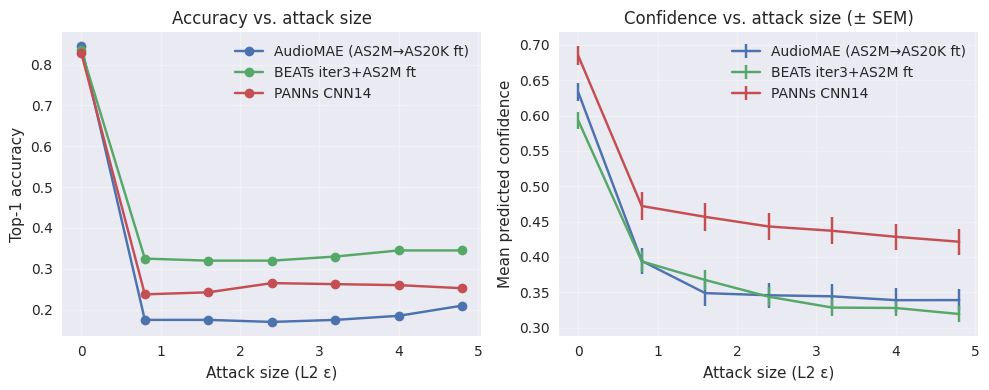

In [2]:
def get_attack_size_from_csv_name(csv_name: str) -> float | None:
    """Parse L2 ε from adversarial_l2_eps_X.csv (e.g. 0p8 → 0.8)."""
    pattern = r"^adversarial_l2_eps_([-+]?[0-9]*\.?[0-9]+|[0-9]+p[0-9]+)(?:plwAW)?\.csv$"
    match = re.match(pattern, csv_name)
    if not match:
        return None
    token = match.group(1)
    try:
        if "p" in token:
            return float(token.replace("p", "."))
        return float(token)
    except ValueError:
        return None


def load_attack_curves_per_model(model_name: str) -> pd.DataFrame:
    """Load per-ε accuracy and confidence aggregates for one audio model."""
    adv_dir = AUDIO_EXP_ROOT / model_name / "adversarial"
    if not adv_dir.exists():
        return pd.DataFrame()

    rows: list[dict[str, float]] = []
    for csv_path in sorted(adv_dir.glob("adversarial_l2_eps_*.csv")):
        eps = get_attack_size_from_csv_name(csv_path.name)
        if eps is None:
            continue
        df = pd.read_csv(csv_path)
        if "is_correct" not in df.columns:
            continue
        if "predicted_softmax" in df.columns:
            conf_col = "predicted_softmax"
        elif "true_class_softmax" in df.columns:
            conf_col = "true_class_softmax"
        else:
            continue
        n = len(df)
        rows.append(
            {
                "epsilon": eps,
                "mean_confidence": float(df[conf_col].mean()),
                "sem_confidence": float(df[conf_col].std() / (n**0.5)) if n > 0 else 0.0,
                "accuracy": float(df["is_correct"].mean()),
            }
        )
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values("epsilon").reset_index(drop=True)


attack_curves: dict[str, pd.DataFrame] = {}
for model_name in AUDIO_MODELS:
    curve_df = load_attack_curves_per_model(model_name)
    if not curve_df.empty:
        attack_curves[model_name] = curve_df
        print(f"{AUDIO_MODEL_LABELS[model_name]} ({model_name}):")
        display(curve_df)

if not attack_curves:
    print(
        "No adversarial CSVs found. Run generate_audio_adversarials.sh for each model "
        f"under {AUDIO_EXP_ROOT}."
    )
else:
    fig, (ax_acc, ax_conf) = plt.subplots(1, 2, figsize=(10, 4))
    for model_name, curve_df in attack_curves.items():
        label = AUDIO_MODEL_LABELS[model_name]
        ax_acc.plot(curve_df["epsilon"], curve_df["accuracy"], "o-", label=label)
        ax_conf.errorbar(
            curve_df["epsilon"],
            curve_df["mean_confidence"],
            yerr=curve_df["sem_confidence"],
            capsize=3,
            label=label,
        )
    ax_acc.set_xlabel("Attack size (L2 ε)")
    ax_acc.set_ylabel("Top-1 accuracy")
    ax_acc.set_title("Accuracy vs. attack size")
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)
    ax_conf.set_xlabel("Attack size (L2 ε)")
    ax_conf.set_ylabel("Mean predicted confidence")
    ax_conf.set_title("Confidence vs. attack size (± SEM)")
    ax_conf.legend()
    ax_conf.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Figure 2: Shared-example cochleagram (model fbank)

One random `sample_idx` present in all `COCHLEAGRAM_MODELS` runs at `COCHLEAGRAM_EPSILON`. Panels show model input features (fbank for AudioMAE; log-mel for PANNs); perturbation is computed in that feature space (preprocess is nonlinear).

In [3]:
def epsilon_to_filename_token(epsilon: float) -> str:
    return format(epsilon, "g").replace(".", "p")


def layer_dir_for_epsilon(model_name: str, epsilon: float, layer_name: str) -> Path:
    token = epsilon_to_filename_token(epsilon)
    return (
        AUDIO_EXP_ROOT
        / model_name
        / "adversarial"
        / f"adversarial_l2_eps_{token}"
        / layer_name
    )


def sample_indices_in_layer_dir(layer_dir: Path) -> set[int]:
    indices: set[int] = set()
    for path in layer_dir.glob("idx*_original.pt"):
        match = re.match(r"^idx(\d+)_", path.name)
        if match:
            indices.add(int(match.group(1)))
    return indices


def resolve_artifact_path(layer_dir: Path, sample_idx: int, suffix: str) -> Path:
    matches = sorted(layer_dir.glob(f"idx{sample_idx:04d}_*{suffix}.pt"))
    if not matches:
        raise FileNotFoundError(
            f"No {suffix} artifact for sample_idx={sample_idx} under {layer_dir}"
        )
    return matches[0]


def load_waveform_from_pt(path: Path) -> np.ndarray:
    tensor = torch.load(path, map_location="cpu", weights_only=False)
    if isinstance(tensor, dict):
        raise TypeError(f"Expected tensor artifact, got dict at {path}")
    waveform = torch.as_tensor(tensor).detach().cpu().float()
    if waveform.ndim == 3:
        waveform = waveform.squeeze(0)
    if waveform.ndim == 2:
        waveform = waveform.mean(dim=0)
    if waveform.ndim != 1:
        raise ValueError(f"Unexpected waveform shape at {path}: {tuple(waveform.shape)}")
    return waveform.numpy()


def load_sample_rate_from_metadata(layer_dir: Path) -> int:
    metadata_path = layer_dir / "metadata.jsonl"
    if not metadata_path.exists():
        return 16_000
    with open(metadata_path, "r", encoding="utf-8") as handle:
        first_line = handle.readline().strip()
    if not first_line:
        return 16_000
    record = json.loads(first_line)
    return int(record.get("sample_rate", record.get("file_sr", 16_000)))


def preprocess_to_fbank_2d(wrapper, waveform_np: np.ndarray, sr: int) -> np.ndarray:
    """Return model input features as [mel_bins, time_frames] for imshow (y=mel, x=time)."""
    from src.models.audio.panns_cnn14 import PannsCnn14AudioModelWrapper

    waveform = torch.as_tensor(waveform_np, dtype=torch.float32).unsqueeze(0)
    if isinstance(wrapper, PannsCnn14AudioModelWrapper):
        features = wrapper.input_log_mel_spectrogram(waveform, sr=sr)
        return features.detach().cpu().numpy()

    features = wrapper.preprocess(waveform, sr=sr)
    arr = features.detach().cpu().numpy()
    while arr.ndim > 2:
        arr = arr.squeeze(0)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2D fbank after squeeze, got shape {arr.shape}")
    # AudioMAE preprocess is [time, mel]; PANNs log-mel is already [mel, time].
    if arr.shape[0] > arr.shape[1]:
        arr = arr.T
    return arr


def ytid_from_artifact_path(path: Path) -> str:
    match = re.match(r"^idx\d+_(.+)_original\.pt$", path.name)
    return match.group(1) if match else path.stem

In [4]:
layer_dirs = {
    model_name: layer_dir_for_epsilon(model_name, COCHLEAGRAM_EPSILON, COCHLEAGRAM_LAYER)
    for model_name in COCHLEAGRAM_MODELS
}

missing = [name for name, path in layer_dirs.items() if not path.exists()]
if missing:
    for model_name in missing:
        adv_root = AUDIO_EXP_ROOT / model_name / "adversarial"
        available = sorted(p.name for p in adv_root.glob("adversarial_l2_eps_*") if p.is_dir())
        print(f"Missing {layer_dirs[model_name]}")
        print(f"  Available attack dirs for {model_name}: {available}")
    raise FileNotFoundError(
        f"Layer dirs not found for epsilon={COCHLEAGRAM_EPSILON}. "
        "Adjust COCHLEAGRAM_EPSILON or regenerate adversarial runs."
    )

index_sets = [sample_indices_in_layer_dir(layer_dirs[m]) for m in COCHLEAGRAM_MODELS]
shared_indices = sorted(set.intersection(*index_sets))
if not shared_indices:
    raise RuntimeError("No shared sample_idx between models at the chosen epsilon.")

rng = random.Random(RANDOM_SEED)
sample_idx = rng.choice(shared_indices)
print(f"Selected sample_idx={sample_idx} (from {len(shared_indices)} shared indices, seed={RANDOM_SEED})")

waveforms_by_model: dict[str, dict[str, np.ndarray]] = {}
sr_by_model: dict[str, int] = {}
for model_name in COCHLEAGRAM_MODELS:
    layer_dir = layer_dirs[model_name]
    sr_by_model[model_name] = load_sample_rate_from_metadata(layer_dir)
    orig_path = resolve_artifact_path(layer_dir, sample_idx, "_original")
    adv_path = resolve_artifact_path(layer_dir, sample_idx, "_adversarial")
    print(f"  {AUDIO_MODEL_LABELS[model_name]}: ytid={ytid_from_artifact_path(orig_path)}, sr={sr_by_model[model_name]}")
    waveforms_by_model[model_name] = {
        "original": load_waveform_from_pt(orig_path),
        "adversarial": load_waveform_from_pt(adv_path),
    }

from src.models.audio.registry import get_audio_model

wrappers = {
    model_name: get_audio_model(model_name, device="cpu", freeze=True)
    for model_name in COCHLEAGRAM_MODELS
}

# Crop AudioMAE display to the first N time frames (full clip has 1024 frames).
WINDOWED_FRAMES = 200
AUDIO_MAE_KEY = None
for m in COCHLEAGRAM_MODELS:
    if "audiomae" in m.lower():
        AUDIO_MAE_KEY = m
        break

fbank_panels: dict[str, dict[str, np.ndarray]] = {}
for model_name in COCHLEAGRAM_MODELS:
    wrapper = wrappers[model_name]
    sr = sr_by_model[model_name]
    orig = preprocess_to_fbank_2d(wrapper, waveforms_by_model[model_name]["original"], sr)
    adv = preprocess_to_fbank_2d(wrapper, waveforms_by_model[model_name]["adversarial"], sr)
    if AUDIO_MAE_KEY is not None and model_name == AUDIO_MAE_KEY:
        orig = orig[:, :WINDOWED_FRAMES]
        adv = adv[:, :WINDOWED_FRAMES]
    fbank_panels[model_name] = {
        "original": orig,
        "adversarial": adv,
        "perturbation": adv - orig,
    }

Selected sample_idx=327 (from 400 shared indices, seed=42)
  AudioMAE (AS2M→AS20K ft): ytid=-QrE0PY0uyw, sr=32000
  PANNs CNN14: ytid=-QrE0PY0uyw, sr=32000


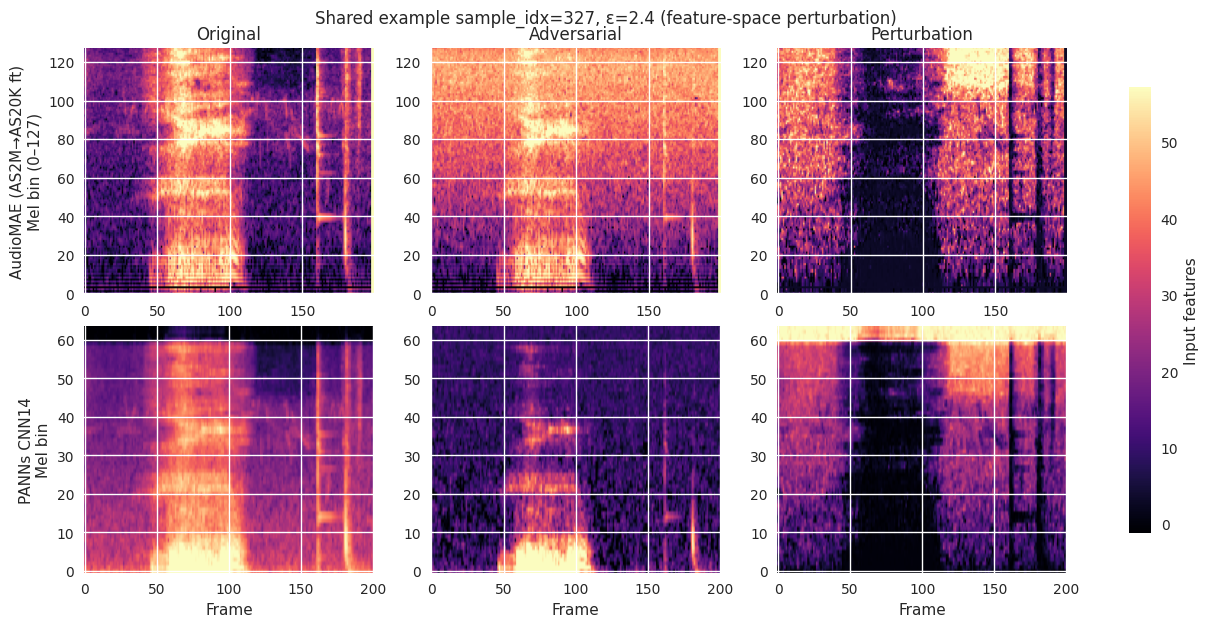

In [5]:
column_keys = ["original", "adversarial", "perturbation"]
column_titles = ["Original", "Adversarial", "Perturbation"]
n_rows = len(COCHLEAGRAM_MODELS)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3 * n_rows), constrained_layout=True)
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)
last_im = None
for row_idx, model_name in enumerate(COCHLEAGRAM_MODELS):
    row_vlims: dict[str, tuple[float, float]] = {}
    for col_key in column_keys:
        values = fbank_panels[model_name][col_key].ravel()
        row_vlims[col_key] = (
            float(np.percentile(values, 2)),
            float(np.percentile(values, 98)),
        )

    for col_idx, col_key in enumerate(column_keys):
        ax = axes[row_idx, col_idx]
        data = fbank_panels[model_name][col_key]  # [mel_bins, time_frames]
        vmin, vmax = row_vlims[col_key]
        last_im = ax.imshow(
            data, origin="lower", aspect="auto", cmap="magma", vmin=vmin, vmax=vmax
        )
        if col_idx == 0:
            ylabel = f"{AUDIO_MODEL_LABELS[model_name]}\nMel bin"
            if AUDIO_MAE_KEY is not None and model_name == AUDIO_MAE_KEY:
                ylabel += f" (0–{data.shape[0] - 1})"
            ax.set_ylabel(ylabel)
        if row_idx == 0:
            ax.set_title(column_titles[col_idx])
        if row_idx == n_rows - 1:
            xlabel = "Frame"
            if AUDIO_MAE_KEY is not None and model_name == AUDIO_MAE_KEY:
                xlabel += f" (0–{data.shape[1] - 1})"
            ax.set_xlabel(xlabel)

if last_im is not None:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.85, label="Input features")
fig.suptitle(
    f"Shared example sample_idx={sample_idx}, ε={COCHLEAGRAM_EPSILON} (feature-space perturbation)",
    y=1.02,
)
plt.show()